In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features, make_lags_dataset

df = prepare_dataset('../trading_small_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date', 'Unnamed: 0'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True)

df = make_lags_dataset(df, [1, 2])

Длина датасета: 153841
Распределение таргета:
dflt_year
0    151926
1      1915
Name: count, dtype: int64
Длина датасета после добавления лаг фичей и отчистки строк с отсутствующими лаг-значениями: 133497
Распределение таргета:
target
0    131675
1      1822
Name: count, dtype: int64


In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")

In [3]:
model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.7591056	best: 0.7591056 (0)	total: 73.9ms	remaining: 12m 19s
200:	test: 0.8964373	best: 0.8964373 (200)	total: 3.16s	remaining: 2m 34s
400:	test: 0.9055611	best: 0.9055611 (400)	total: 6.06s	remaining: 2m 25s
600:	test: 0.9084926	best: 0.9084926 (600)	total: 8.97s	remaining: 2m 20s
800:	test: 0.9101117	best: 0.9101163 (799)	total: 11.8s	remaining: 2m 15s
1000:	test: 0.9117360	best: 0.9117522 (999)	total: 14.7s	remaining: 2m 12s
1200:	test: 0.9124983	best: 0.9125329 (1180)	total: 17.5s	remaining: 2m 8s
1400:	test: 0.9130184	best: 0.9130605 (1340)	total: 20.4s	remaining: 2m 4s
1600:	test: 0.9135368	best: 0.9135368 (1600)	total: 23.2s	remaining: 2m 1s
1800:	test: 0.9139825	best: 0.9140027 (1785)	total: 26s	remaining: 1m 58s
2000:	test: 0.9142824	best: 0.9143037 (1992)	total: 28.8s	remaining: 1m 55s
2200:	test: 0.9149455	best: 0.9149783 (2196)	total: 31.6s	remaining: 1m 52s
2400:	test: 0.9153070	best: 0.9153364 (2398)	total: 34.5s	remaining: 1m 49s
2600:	test: 0.9154702	best: 0.

In [4]:
metrics = calculate_metrics(model, X_test, y_test)

AUC: 0.9406158380800804
Brier: 0.10627892607739153
LogLoss: 0.4199216686149358



Top 20 features by importance:
                                 feature  importance
0              debt_to_total_liabilities    7.734574
1         debt_to_total_liabilities_lag1    6.356198
2                     absolute_liquidity    4.878739
3                      net_profit_margin    3.121304
4                  total_assets_turnover    2.243769
5            receivables_to_total_assets    2.098587
6             total_assets_turnover_lag1    2.059443
7                             roa_ru_tax    1.989207
8                                    roa    1.815544
9             total_assets_turnover_lag2    1.702894
10                    inventory_turnover    1.698651
11                  receivables_turnover    1.687661
12                     payables_turnover    1.528091
13      receivables_to_total_assets_lag1    1.306223
14                     2110_revenue_lag2    1.272796
15                                   roe    1.234438
16                     2110_revenue_lag1    1.165356
17  working_ca

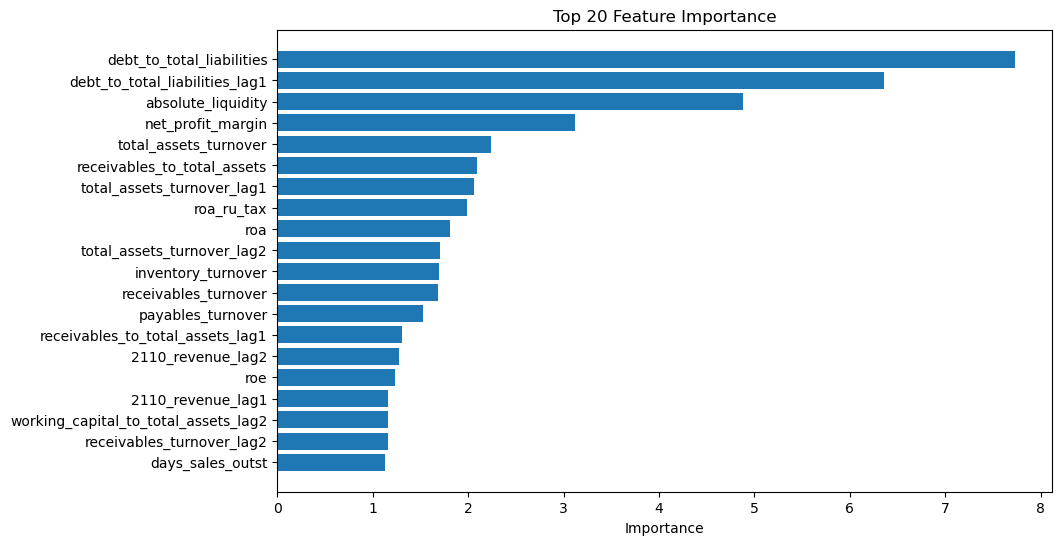

In [5]:
fi_df = get_most_important_features(model, show=20)

In [6]:
from utils.common import calibrate_model

calibrated_model = calibrate_model(model, X_val, y_val)

In [7]:
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

AUC: 0.9384699855503433
Brier: 0.08428839475749804
LogLoss: 0.28833331663398065


In [8]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='small_df_lag2',
         save_data=False)

'exp/small_df_lag2'